In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from scipy.stats import norm
from hmmlearn.hmm import GaussianHMM
from arch import arch_model

# Smart path detection
potential_paths = [
    "../data/processed/eurusd_clean_returns_jan2026.parquet",
    "code/data/processed/eurusd_clean_returns_jan2026.parquet",
    "./code/data/processed/eurusd_clean_returns_jan2026.parquet"
]
data_path = next((p for p in potential_paths if os.path.exists(p)), potential_paths[0])
model_dir = "../models/"
os.makedirs(model_dir, exist_ok=True)
print(f"Using data path: {data_path}")

Using data path: ../data/processed/eurusd_clean_returns_jan2026.parquet


In [2]:
df = pd.read_parquet(data_path)
y = df['returns'].values
T = len(y)
ALPHA = 0.05
z = norm.ppf(1 - ALPHA / 2)

print(f"Loaded {T} observations. Sample Std: {np.std(y):.6f}")

Loaded 16436 observations. Sample Std: 0.000116


In [3]:
std_global = np.std(y)
mu_global = np.mean(y)

# Baseline: Always Mean
l0, u0 = mu_global - z*std_global, mu_global + z*std_global

# Baseline: Repeat Last (Momentum)
l_rep, u_rep = y[:-1] - z*std_global, y[:-1] + z*std_global
y_true = y[1:] # Align for scoring

print("Baselines ready.")

Baselines ready.


In [4]:
X = y.reshape(-1, 1)
hmm_model = GaussianHMM(n_components=2, covariance_type="full", n_iter=100)
hmm_model.fit(X)

joblib.dump(hmm_model, os.path.join(model_dir, "hmm_eurusd_jan2026.pkl"))
print("HMM Fit Complete.")

Model is not converging.  Current: 102210.57323390534 is not greater than 102211.27135352168. Delta is -0.6981196163396817


HMM Fit Complete.


In [ ]:
smoothed_probs = hmm_model.predict_proba(X) 
transmat = hmm_model.transmat_

# Predict state for t+1 using only info from t
pred_probs = np.dot(smoothed_probs[:-1], transmat)

mus = hmm_model.means_.flatten()
sigs = np.sqrt(hmm_model.covars_.flatten())

y_hat_hmm = np.sum(pred_probs * mus, axis=1)
y_var_hmm = np.sum(pred_probs * (sigs**2 + (mus - y_hat_hmm.reshape(-1,1))**2), axis=1)
y_std_hmm = np.sqrt(y_var_hmm)

l_hmm, u_hmm = y_hat_hmm - z*y_std_hmm, y_hat_hmm + z*y_std_hmm
print("HMM Intervals generated.")

HMM Intervals generated.


In [6]:
g_model = arch_model(y, mean='Zero', vol='Garch', p=1, q=1)
g_res = g_model.fit(disp='off')

# Get conditional volatility for t=1...T-1
y_std_g = g_res.conditional_volatility[1:]
l_g, u_g = 0 - z*y_std_g, 0 + z*y_std_g

joblib.dump(g_res, os.path.join(model_dir, "garch_eurusd_jan2026.pkl"))
print("GARCH Fit Complete.")

c:\Users\ofurn\Dokumenter\Github\stk-mat2011\.venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.337e-08. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1e+04 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


GARCH Fit Complete.


C:\Users\ofurn\AppData\Local\Temp\ipykernel_1132\1034347394.py:2: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  g_res = g_model.fit(disp='off')


In [7]:
def score(y, l, u):
    if np.isscalar(l): l = np.full_like(y, l)
    if np.isscalar(u): u = np.full_like(y, u)
    cov = np.mean((y >= l) & (y <= u))
    wid = np.mean(u - l)
    is_v = np.mean((u - l) + (2/ALPHA)*np.maximum(l-y, 0) + (2/ALPHA)*np.maximum(y-u, 0))
    return cov, wid, is_v

res_list = {
    "Baseline: Global Std": score(y_true, l0, u0),
    "Baseline: Repeat Last": score(y_true, l_rep, u_rep),
    "HMM (One-Step Pred)": score(y_true, l_hmm, u_hmm),
    "GARCH(1,1)": score(y_true, l_g, u_g)
}

print("=" * 80)
print("REAL DATA ANALYSIS: EUR/USD JAN 2026 ".center(80))
print("=" * 80)
print(f"{'Model':<25} | {'Coverage':>8} | {'Avg Width':>10} | {'IS (↓)':>10}")
print("-" * 80)
for name, m in res_list.items():
    print(f"{name:<25} | {m[0]:>8.4f} | {m[1]:>10.4f} | {m[2]:>10.4f}")
print("=" * 80)

                     REAL DATA ANALYSIS: EUR/USD JAN 2026                       
Model                     | Coverage |  Avg Width |     IS (↓)
--------------------------------------------------------------------------------
Baseline: Global Std      |   0.9838 |     0.0005 |     0.0006
Baseline: Repeat Last     |   0.9618 |     0.0005 |     0.0007
HMM (One-Step Pred)       |   0.9997 |     0.0043 |     0.0044
GARCH(1,1)                |   0.9804 |     0.0004 |     0.0005


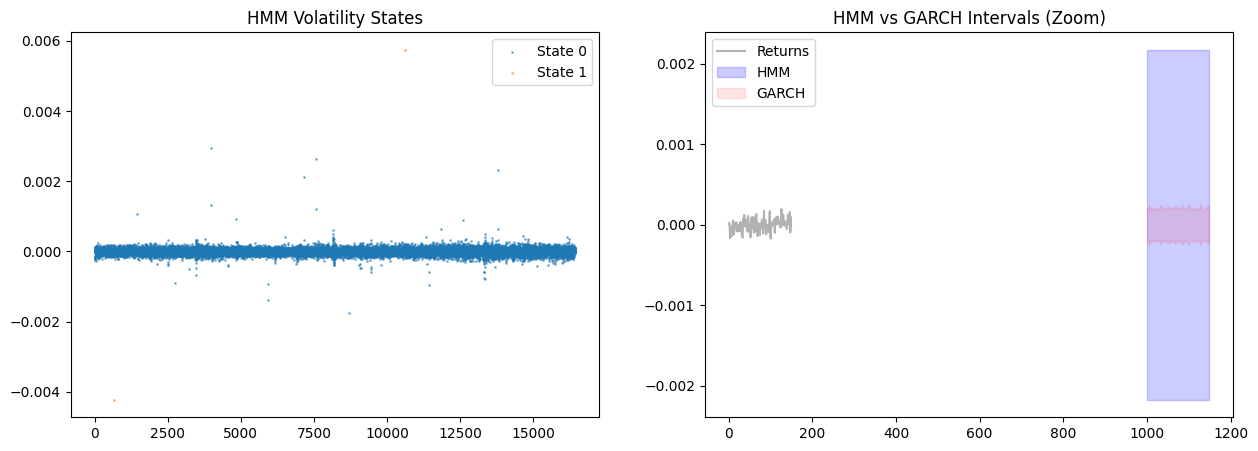

In [8]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("HMM Volatility States")
s = hmm_model.predict(X)
for i in range(hmm_model.n_components):
    mask = s == i
    plt.scatter(np.where(mask)[0], y[mask], s=1, label=f'State {i}', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.title("HMM vs GARCH Intervals (Zoom)")
chunk = range(1000, 1150)
plt.plot(y_true[chunk], color='black', alpha=0.3, label='Returns')
plt.fill_between(chunk, l_hmm[chunk], u_hmm[chunk], color='blue', alpha=0.2, label='HMM')
plt.fill_between(chunk, l_g[chunk], u_g[chunk], color='red', alpha=0.1, label='GARCH')
plt.legend()
plt.show()